## Imports de librerías a utilizar

In [148]:
import seaborn as sns 
import matplotlib.pyplot as plt 
import numpy as np
import tensorflow as tf
import pandas as pd

## Generación de archivo Parquet uniendo los dataframes de training_setA y training_setB

In [149]:
from pathlib import Path

def load_dataset(folder, set):
    dfs = []

    for f in sorted(Path(folder).glob("*.psv")):
        df = pd.read_csv(f, sep="|")
        df["patient_id"] = f.stem
        df["hospital"] = set
        dfs.append(df)
    return pd.concat(dfs, ignore_index=True)

sepsis_a = load_dataset("../datos/sepsis-2019/training/training_setA", 'A')
sepsis_b = load_dataset("../datos/sepsis-2019/training/training_setB", 'B')

sepsis_df = pd.concat([sepsis_a, sepsis_b], ignore_index=True)

sepsis_parquet = sepsis_df.to_parquet("sepsis_parquet_raw.parquet", index=False)



KeyboardInterrupt: 

## Carga de los datos en crudo de Sepsis desde el Parquet creado

In [150]:
sepsis = pd.read_parquet(
    "sepsis_parquet_raw.parquet"
)

sepsis_df = sepsis.copy()

## Establecer los rangos de los outliers para convertirlos a valores NaN

In [151]:
outliers_cols = [
    "HR", "O2Sat", "Temp", "SBP", "MAP", "Resp"
]

outliers_ranges = [
    (20, 250), (50, 100), (30, 43), (40, 280), (20, 200), (4, 70)
]

for i in range(6):
    col = outliers_cols[i]
    lo, hi = outliers_ranges[i]
    sepsis_df.loc[~sepsis_df[col].between(lo, hi),col] = np.nan


sepsis_df[["HR", "O2Sat", "Temp", "SBP", "MAP", "Resp"]].describe().loc[["min", "max"]]


,HR,O2Sat,Temp,SBP,MAP,Resp
min,20.0,50.0,30.00,40.0,20.0,4.0
max,223.0,100.0,42.22,280.0,200.0,70.0


## Rellenar columnas de datos clínicos con los datos del último paciente

In [152]:
no_clinic_columns = [
    "patient_id", "hospital", "Age", "Gender", "Unit1", "Unit2",
               "HospAdmTime", "ICULOS", "SepsisLabel"
]

clinic_columns = [c for c in sepsis_df.columns if c not in no_clinic_columns]

sepsis_df[clinic_columns] = sepsis_df.groupby('patient_id')[clinic_columns].ffill()

sepsis_df

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,HCO3,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,hospital
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001,A
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001,A
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001,A
3,90.0,95.0,NaN,122.0,86.00,NaN,30.0,NaN,24.0,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001,A
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,NaN,24.0,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,80.0,96.0,36.4,115.0,87.00,65.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,31,0,p120000,B
1552206,74.0,97.0,36.4,114.0,83.00,67.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,32,0,p120000,B
1552207,78.0,98.0,36.4,110.0,83.00,69.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,33,0,p120000,B
1552208,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,34,0,p120000,B


## Eliminar columnas vacías

In [153]:
null_values = sepsis_df.isna().mean().sort_values(ascending=False)

sepsis_df = sepsis_df.drop(columns=null_values[null_values > 0.80].index)

sepsis_df

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,BaseExcess,HCO3,FiO2,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,hospital
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,1,0,p000001,A
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001,A
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001,A
3,90.0,95.0,NaN,122.0,86.00,NaN,30.0,24.0,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001,A
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,24.0,NaN,0.28,...,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,80.0,96.0,36.4,115.0,87.00,65.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,31,0,p120000,B
1552206,74.0,97.0,36.4,114.0,83.00,67.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,32,0,p120000,B
1552207,78.0,98.0,36.4,110.0,83.00,69.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,33,0,p120000,B
1552208,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,34,0,p120000,B


## Eliminar registros sin ningún dato clínico

In [154]:
clinic_columns = [c for c in clinic_columns if c in sepsis_df.columns]
sepsis_df = sepsis_df.dropna(subset=clinic_columns, how="all")
sepsis_df

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,BaseExcess,HCO3,FiO2,...,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,hospital
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,2,0,p000001,A
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,3,0,p000001,A
3,90.0,95.0,NaN,122.0,86.00,NaN,30.0,24.0,NaN,NaN,...,NaN,83.14,0,NaN,NaN,-0.03,4,0,p000001,A
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,24.0,NaN,0.28,...,NaN,83.14,0,NaN,NaN,-0.03,5,0,p000001,A
5,110.0,91.0,NaN,122.0,91.33,NaN,22.0,24.0,NaN,0.28,...,NaN,83.14,0,NaN,NaN,-0.03,6,0,p000001,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,80.0,96.0,36.4,115.0,87.00,65.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,31,0,p120000,B
1552206,74.0,97.0,36.4,114.0,83.00,67.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,32,0,p120000,B
1552207,78.0,98.0,36.4,110.0,83.00,69.0,15.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,33,0,p120000,B
1552208,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,...,216.0,62.00,0,NaN,NaN,0.00,34,0,p120000,B


## Feature Engineering para crear nuevas columnas sobre las columnas que ya tenemos

In [155]:
vital_constants = ["HR", "O2Sat", "Temp", "SBP", "MAP", "Resp"]

# Variables por registro o observaciñon que no tienen datos rellenados
sepsis_df['reg_w_data'] = sepsis_df[clinic_columns].isna().sum(axis=1)

# Índice de shock anafiláctico, nos sirve para comparar la gravedad del paciente
sepsis_df['shock_index'] = sepsis_df['HR'] / sepsis_df['SBP']

sepsis_df

,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,BaseExcess,HCO3,FiO2,...,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,patient_id,hospital,reg_w_data,shock_index
1,97.0,95.0,NaN,98.0,75.33,NaN,19.0,NaN,NaN,NaN,...,0,NaN,NaN,-0.03,2,0,p000001,A,25,0.989796
2,89.0,99.0,NaN,122.0,86.00,NaN,22.0,NaN,NaN,NaN,...,0,NaN,NaN,-0.03,3,0,p000001,A,25,0.729508
3,90.0,95.0,NaN,122.0,86.00,NaN,30.0,24.0,NaN,NaN,...,0,NaN,NaN,-0.03,4,0,p000001,A,22,0.737705
4,103.0,88.5,NaN,122.0,91.33,NaN,24.5,24.0,NaN,0.28,...,0,NaN,NaN,-0.03,5,0,p000001,A,21,0.844262
5,110.0,91.0,NaN,122.0,91.33,NaN,22.0,24.0,NaN,0.28,...,0,NaN,NaN,-0.03,6,0,p000001,A,21,0.901639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1552205,80.0,96.0,36.4,115.0,87.00,65.0,15.0,NaN,NaN,NaN,...,0,NaN,NaN,0.00,31,0,p120000,B,8,0.695652
1552206,74.0,97.0,36.4,114.0,83.00,67.0,15.0,NaN,NaN,NaN,...,0,NaN,NaN,0.00,32,0,p120000,B,8,0.649123
1552207,78.0,98.0,36.4,110.0,83.00,69.0,15.0,NaN,NaN,NaN,...,0,NaN,NaN,0.00,33,0,p120000,B,8,0.709091
1552208,82.0,99.0,36.6,124.0,91.00,71.0,16.0,NaN,NaN,NaN,...,0,NaN,NaN,0.00,34,0,p120000,B,8,0.661290


# Separación de datos entre Train y Test

In [156]:
patients = sepsis_df['patient_id'].drop_duplicates().sample(frac=1, random_state=42)
test_ids = patients[:int(len(patients) * 0.2)]

pre_test = sepsis_df['patient_id'].isin(test_ids)
train = sepsis_df[~pre_test].copy()
test = sepsis_df[pre_test].copy()

train
print(len(train), len(test))

1214397 303712


## Rellenar datos vacíos con las medianas de cada columna

In [157]:
medians = train.median(numeric_only=True)
train = train.fillna(medians)
test = test.fillna(medians)

# Verificación de que no ha quedado ningún dato vacío y todos estan rellenados
print(train.isna().sum().sum(), test.isna().sum().sum())

0 0


## Separación en datos de entrada y etiquetas

In [158]:
ID = ["patient_id", "hospital"]

X_train = train.drop(columns=['SepsisLabel'] + ID)
y_train = train['SepsisLabel']

X_test = test.drop(columns=['SepsisLabel'] + ID)
y_test = test['SepsisLabel']

print(X_train.shape) # Usaríamos la forma de entrada (38,)
print(y_train.shape)

print(X_train.select_dtypes(exclude="number").columns.tolist()) # Verificamos que hemos eliminado las columnas que contenian texto

X_train = X_train.to_numpy().astype("float32")
y_train = y_train.to_numpy().astype("float32")
X_test = X_test.to_numpy().astype("float32")
y_test = y_test.to_numpy().astype("float32")

train_patients = train["patient_id"].drop_duplicates().sample(frac=1, random_state=42)
val_ids = train_patients[:int(len(train_patients) * 0.2)]
in_val = train["patient_id"].isin(val_ids).to_numpy()

X_tr, y_tr = X_train[~in_val], y_train[~in_val]
X_val, y_val = X_train[in_val], y_train[in_val]

(1214397, 38)
(1214397,)
[]


## Creación del modelo y evaluación del mismo (Random Forest)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import log_loss

rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=50,
    max_samples=0.2,
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42,
)
rf.fit(X_tr, y_tr)

pred_val = rf.predict_proba(X_val)[:, 1]
pred_rf = rf.predict_proba(X_test)[:, 1]

print("AUPRC validación:", average_precision_score(y_val, pred_val))
print("AUPRC test:", average_precision_score(y_test, pred_rf))
print("Pérdida validación:", log_loss(y_val, pred_val))
print("Pérdida test:", log_loss(y_test, pred_rf))
print("Accuracy validación:", accuracy_score(y_val, pred_val > 0.5))
print("Accuracy test:", accuracy_score(y_test, pred_rf > 0.5))

AUPRC validación: 0.10070014547153437
AUPRC test: 0.09406620414960179
Pérdida validación: 0.23353684989722617
Pérdida test: 0.22498583752349255
Accuracy validación: 0.9377270157370461
Accuracy test: 0.9421623116636814


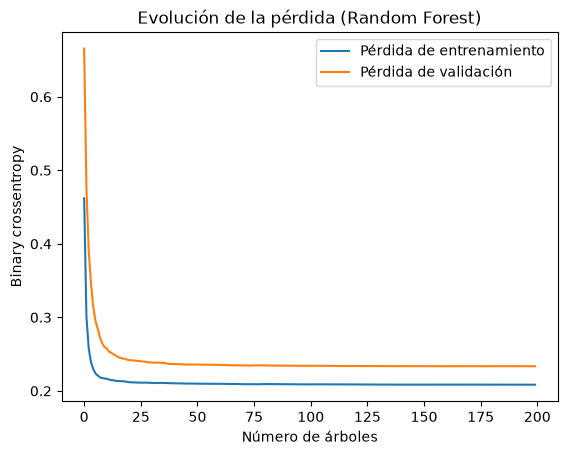

In [174]:
from sklearn.metrics import log_loss

sum_tr = np.zeros(len(X_tr))
sum_val = np.zeros(len(X_val))
loss_tr, loss_val = [], []

for i, tree in enumerate(rf.estimators_, start=1):
    sum_tr += tree.predict_proba(X_tr)[:, 1]
    sum_val += tree.predict_proba(X_val)[:, 1]
    loss_tr.append(log_loss(y_tr, sum_tr / i))
    loss_val.append(log_loss(y_val, sum_val / i))

plt.plot(loss_tr, label="Pérdida de entrenamiento")
plt.plot(loss_val, label="Pérdida de validación")

plt.xlabel("Número de árboles")
plt.ylabel("Binary crossentropy")
plt.title("Evolución de la pérdida (Random Forest)")
plt.legend()
plt.show()